

## Clasificación Multi-Etiqueta de Artículos de Noticias de la BBC usando Transformers


Se requiere realizar un modelo Deep Learning usando Transformers, para realizar una clasificación multiclase en un conjunto de noticias de la BBC.

Para lograr este modelo se realizarán los siguientes pasos:

1. Importar las librerías necesarias.
2. Realizar extracción de los datos y analisis descriptivo.
3. Partición del dataset en entrenamiento, validación y prueba
4. Cargar tokenizador y modelo preentrenado de DistilBERT
5. Creación de Red Neuronal para clasificación multiclase
6. Análisis de resultados.

In [167]:
! pip install kagglehub


[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip


## 1. Importar librerías requeridas

In [168]:
import kagglehub

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from transformers import DistilBertTokenizer, DistilBertModel
import torch.optim as optim

import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import os
warnings.filterwarnings('ignore')

In [169]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 2. Extracción de los datos y análisis descriptivo

In [170]:
# Descargar última versión del dataset con la API de Kaggle
data_dir = kagglehub.dataset_download("jacopoferretti/bbc-articles-dataset")

print("Path to dataset files:", data_dir)
data_dir

Path to dataset files: /root/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/8


'/root/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/8'

In [171]:
file_path = os.path.join(data_dir, "bbc_news_text_complexity_summarization.csv")
df = pd.read_csv(file_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2127 entries, 0 to 2126
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   text                          2127 non-null   object 
 1   labels                        2127 non-null   object 
 2   no_sentences                  2127 non-null   int64  
 3   Flesch Reading Ease Score     2127 non-null   float64
 4   Dale-Chall Readability Score  2127 non-null   float64
 5   text_rank_summary             2127 non-null   object 
 6   lsa_summary                   2127 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 116.4+ KB


In [172]:
df.head()

,text,labels,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score,text_rank_summary,lsa_summary
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,26,62.17,9.72,It hopes to increase subscribers by offering t...,Its profits were buoyed by one-off gains which...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,17,65.56,9.09,The dollar has hit its highest level against t...,"""I think the chairman's taking a much more san..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,14,69.21,9.66,The owners of embattled Russian oil giant Yuko...,Yukos' owner Menatep Group says it will ask Ro...
3,High fuel prices hit BA's profits\n\nBritish A...,business,24,62.98,9.86,Looking ahead to its full year results to Marc...,"Rod Eddington, BA's chief executive, said the ..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,17,70.63,10.23,Reports in the Wall Street Journal and the Fin...,Shares in UK drinks and food firm Allied Domec...


In [173]:
df.describe()

,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score
count,2127.000000,2127.000000,2127.000000
mean,18.968030,63.645548,9.145581
std,13.022952,8.466323,0.823067
min,4.000000,33.410000,6.400000
25%,12.000000,58.210000,8.630000
50%,17.000000,63.430000,9.130000
75%,23.000000,69.310000,9.650000
max,252.000000,87.760000,14.200000


In [174]:
print(df['labels'].value_counts())

sport            505
business         503
politics         403
entertainment    369
tech             347
Name: labels, dtype: int64


El dataset se encuentra balanceado. Hay una distribución homogénea entre los dos tipos de noticia.

count    2127.000000
mean      384.112835
std       241.399741
min        89.000000
25%       245.000000
50%       331.000000
75%       471.000000
max      4432.000000
Name: review_length, dtype: float64


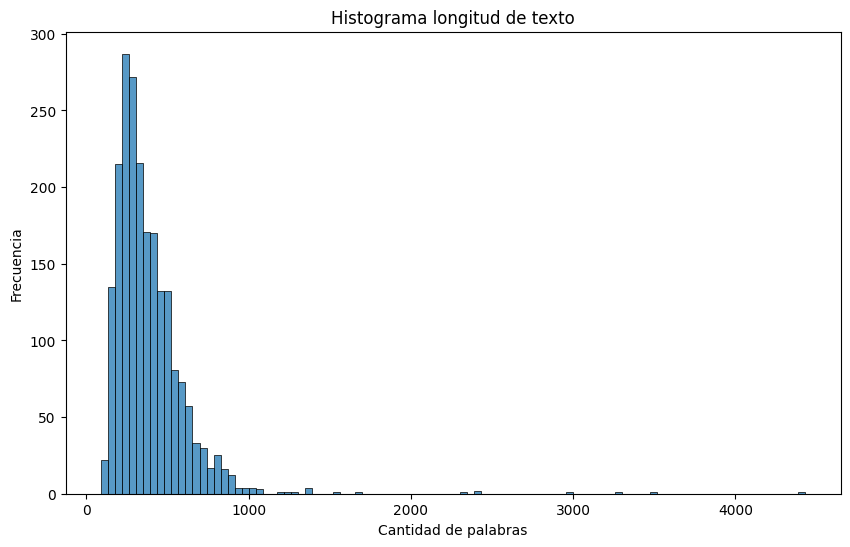

In [175]:
df['review_length'] = df['text'].apply(lambda x: len(str(x).split()))

print(df['review_length'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['review_length'], bins=100)
plt.title('Histograma longitud de texto')
plt.ylabel('Frecuencia')
plt.xlabel('Cantidad de palabras')
plt.show()

Se seleccionan únicamente las columnas requeridas, el texto de la noticia y las etiquetas. Luego se utiliza el método `LabelEncoder` para convertir las etiquetas categóricas a numéricas.

In [176]:
#Se seleccionan únicamente las columnas requeridas, el texto de la noticia y las etiquetas
df = df[['text', 'labels']]

# Convertir etiquetas
label_encoder = LabelEncoder()
df["label_numeric"] = label_encoder.fit_transform(df["labels"])

In [177]:
df[['label_numeric', 'labels']].value_counts()

label_numeric  labels       
3              sport            505
0              business         503
2              politics         403
1              entertainment    369
4              tech             347
dtype: int64

In [178]:
df.head()

,text,labels,label_numeric
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,0
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,0
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,0
3,High fuel prices hit BA's profits\n\nBritish A...,business,0
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,0


## 3. Partición del dataset en entrenamiento, validación y prueba.

Se hará una partición inicial de 70% para entrenamiento y 30% para validación+prueba, luego de la partición del 30% se utilizará 50% para la validación y 50% para pruebas. Las particiones finales serán de 70% entrenmiento, 15% validación y 15% prueba.

In [179]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["text"].tolist(),
    df["label_numeric"].tolist(),
    test_size=0.3,
    stratify=df["label_numeric"],
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

## 4. Cargar tokenizador y modelo preentrenado de DistilBERT

Se instancia el tokenizador y el modelo BERT que se utilizará para generar los embeddings de los textos.

In [180]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = DistilBertModel.from_pretrained('distilbert-base-uncased')
bert_model.to(device)
bert_model.eval()

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): MultiHeadSelfAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Li

La función `tokenize_and_vectorize` recibe los textos y los tokeniza para luego utilizarlos en el modelo de DistilBERT, luego de pasar por el modelo se retornan los tokens `[CLS]` utilizados para clasificación que se enecuentran en la primera posición del vector tokenizado que retorna el modelo, este token captura el significado del texto para luego ser utilizado en el modelo de clasificación multiclase.

Se utiliza el parámetro `padding` para agregar tokens de relleno y todos los textos tengan la misma longitud.
Se utiliza el parámetro `truncation=True` que permite que los textos tengan una longitud máxima de 512 tokens. Se agrega el parámetro `attention_mask` para que el modelo se enfoque sólo en los tokens reales y no en los generados en el padding.

In [181]:
def tokenize_and_vectorize(texts, tokenizer, model, device='cuda', batch_size=32):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]

        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors="pt",
            max_length=512
        )

        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu())

    return torch.cat(all_embeddings, dim=0)

In [182]:
def prepare_dataset(texts, labels, tokenizer, model):
    embeddings = tokenize_and_vectorize(texts, tokenizer, model)
    labels_tensor = torch.tensor(labels)
    return embeddings, labels_tensor

Se realiza la tokenización y embedding de los conjuntos de entrenamiento, validación y prueba.

In [183]:
train_embeddings, train_labels_tensor = prepare_dataset(train_texts, train_labels, tokenizer, bert_model)
val_embeddings, val_labels_tensor = prepare_dataset(val_texts, val_labels, tokenizer, bert_model)
test_embeddings, test_labels_tensor = prepare_dataset(test_texts, test_labels, tokenizer, bert_model)

In [184]:
train_embeddings.shape

torch.Size([1488, 768])

## 5. Creación de Red Neuronal para clasificación multiclase

Se crea una red neuronal para la clasificación multiclase final, se utliza una capa Linear de entreada con las dimensiones del vector que entrega el modelo DistilBERT, luego se hace una reducción de dimensinoalidad a una capa oculta de 256 y finalmente se utilizará una capa de salida de dimensión 5 para las clases. Se utilizará ReLU como función de activación para añadir la no-linealidad requerida y una capa de Dropout para mitigar el sobreajuste.

In [185]:
def build_model(input_dim=768, hidden_dim=256, output_dim=5):
    return nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(hidden_dim, output_dim)
    )

### 5.1 Entrenamiento RN

Se realizará el entrenamiento de la red neuronal utilizando como función de pérdida `CrossEntropyLoss` que es utilizada en clasificaciones multiclase y que utiliza softmax por defecto para la capa final. Se utilizará un optimizador `Adam` y se evaluará el modelo con la precisión en el conjunto de validación durante 700 épocas.

In [186]:
input_dim = train_embeddings.shape[1]            
num_classes = len(label_encoder.classes_)      

model = build_model(input_dim, 256, num_classes).to(device)
criterion = nn.CrossEntropyLoss()        
optimizer = optim.Adam(model.parameters(), lr=2e-5)

train_embeddings = train_embeddings.to(device)
train_labels_tensor = train_labels_tensor.to(device)
val_embeddings = val_embeddings.to(device)
val_labels_tensor = val_labels_tensor.to(device)

train_accuracies = []
val_accuracies = []


# Entrenamiento
for epoch in range(700):
    model.train()
    optimizer.zero_grad()
    outputs = model(train_embeddings)              # Entrenamiento hacia adelante (Forward)
    loss = criterion(outputs, train_labels_tensor) # Calcular pérdida
    loss.backward()                                # Backpropagation
    optimizer.step()                               # Actualizar pesos
    
    train_preds = torch.argmax(outputs, dim=1)
    train_acc = (train_preds == train_labels_tensor).float().mean().item()
    train_accuracies.append(train_acc)
    
    # Evaluación en el conjunto de validación
    model.eval()
    with torch.no_grad():
        val_outputs = model(val_embeddings)
        val_preds = torch.argmax(val_outputs, dim=1)
        acc = (val_preds == val_labels_tensor).float().mean().item()
        val_accuracies.append(acc)
        print(f"Época {epoch+1}, Pérdida: {loss.item():.4f}, Accuracy en validación: {acc:.4f}")

Época 1, Pérdida: 1.6202, Accuracy en validación: 0.2132
Época 2, Pérdida: 1.6191, Accuracy en validación: 0.2288
Época 3, Pérdida: 1.6154, Accuracy en validación: 0.2320
Época 4, Pérdida: 1.6146, Accuracy en validación: 0.2351
Época 5, Pérdida: 1.6073, Accuracy en validación: 0.2320
Época 6, Pérdida: 1.6072, Accuracy en validación: 0.2414
Época 7, Pérdida: 1.6011, Accuracy en validación: 0.2445
Época 8, Pérdida: 1.6025, Accuracy en validación: 0.2476
Época 9, Pérdida: 1.5981, Accuracy en validación: 0.2476
Época 10, Pérdida: 1.5974, Accuracy en validación: 0.2508
Época 11, Pérdida: 1.5940, Accuracy en validación: 0.2508
Época 12, Pérdida: 1.5898, Accuracy en validación: 0.2508
Época 13, Pérdida: 1.5884, Accuracy en validación: 0.2539
Época 14, Pérdida: 1.5846, Accuracy en validación: 0.2539
Época 15, Pérdida: 1.5806, Accuracy en validación: 0.2539
Época 16, Pérdida: 1.5815, Accuracy en validación: 0.2571
Época 17, Pérdida: 1.5789, Accuracy en validación: 0.2571
Época 18, Pérdida: 1.57

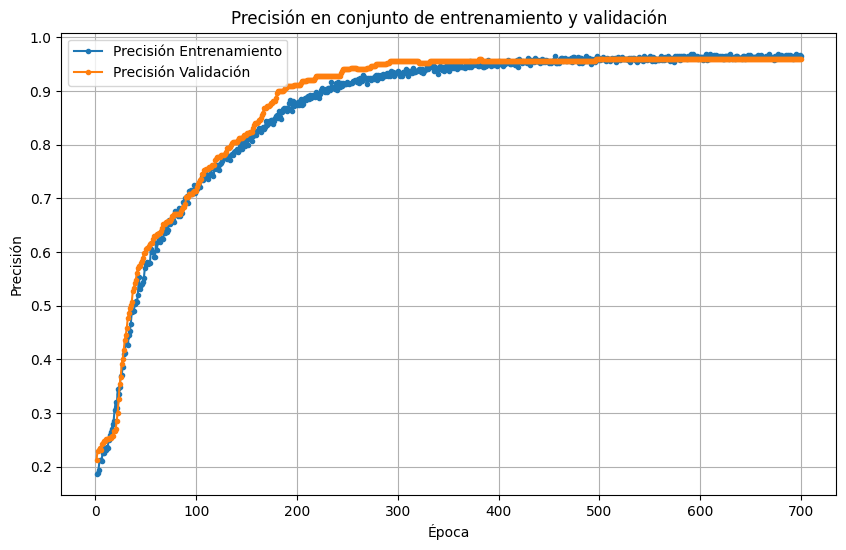

In [187]:
epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracies, label='Precisión Entrenamiento', marker='.')
plt.plot(epochs, val_accuracies, label='Precisión Validación', marker='.')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Precisión en conjunto de entrenamiento y validación')
plt.legend()
plt.grid(True)
plt.show()


## 6. Análisis de resultados

Se evalúa el modelo obtenido en el conjunto de prueba para ver los resultados de precisión, recall y f1-score para las distintas clases.

In [188]:
model.eval()
test_embeddings = test_embeddings.to(device)
test_labels_tensor = test_labels_tensor.to(device)

with torch.no_grad():
    test_outputs = model(test_embeddings)
    predicted_labels = torch.argmax(test_outputs, dim=1)

print("\nClassification Report:\n")
print(classification_report(test_labels_tensor.cpu(), predicted_labels.cpu(), target_names=label_encoder.classes_))



Classification Report:

               precision    recall  f1-score   support

     business       0.97      0.96      0.97        76
entertainment       1.00      1.00      1.00        55
     politics       0.94      0.98      0.96        61
        sport       1.00      1.00      1.00        76
         tech       0.98      0.94      0.96        52

     accuracy                           0.98       320
    macro avg       0.98      0.98      0.98       320
 weighted avg       0.98      0.98      0.98       320



### 6.1. Resultados Cuantitativos

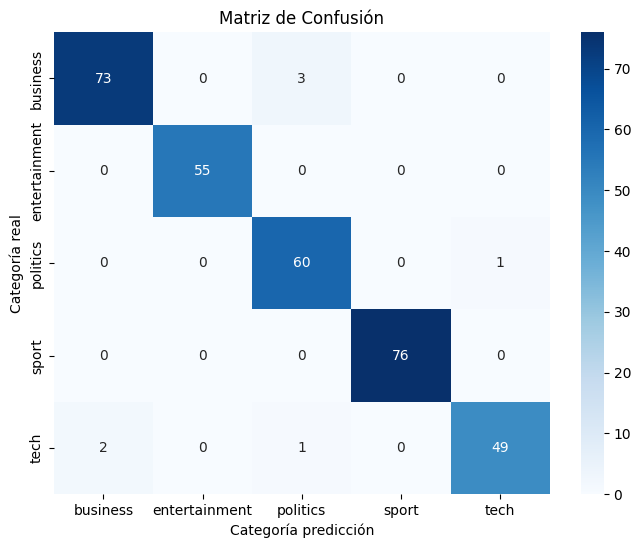

In [189]:
cm = confusion_matrix(test_labels_tensor.cpu(), predicted_labels.cpu())
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Categoría predicción')
plt.ylabel('Categoría real')
plt.title('Matriz de Confusión')
plt.show()

### 6.2. Resultados Cualitativos

Se muestra un listado con las noticias que fueron clasificadas de forma incorrecta para establecer las posibles causas donde el modelo puede estar fallando.

In [190]:
true_labels = label_encoder.inverse_transform(test_labels_tensor.cpu().numpy())
predicted_labels_decoded = label_encoder.inverse_transform(predicted_labels.cpu().numpy())

# Convert test_texts to a list if needed
test_texts = list(test_texts)

# Print mismatches
print("Noticias con clasificación errónea:\n")
for text, true, pred in zip(test_texts, true_labels, predicted_labels_decoded):
    if true != pred:
        print(f"Texto: {text[:300]}...")  # Show only the first 300 characters
        print(f"Etiqueta real: {true}")
        print(f"Etiqueta predicción: {pred}")
        print("-" * 80)

Noticias con clasificación errónea:

Texto: Golden rule 'intact' says ex-aide

Chancellor Gordon Brown will meet his golden economic rule "with a margin to spare", according to his former chief economic adviser.

Formerly one of Mr Brown's closest Treasury aides, Ed Balls hinted at a Budget giveaway on 16 March. He said he hoped more would be...
Etiqueta real: business
Etiqueta predicción: politics
--------------------------------------------------------------------------------
Texto: Call for action on internet scam

Phone companies are not doing enough to warn customers about internet "rogue-dialling" scams, according to premium phone line regulator Icstis.

It has received 45,000 complaints in recent months about dial-up internet connections diverting to premium rate numbers w...
Etiqueta real: tech
Etiqueta predicción: politics
--------------------------------------------------------------------------------
Texto: US bank boss hails 'genius' Smith

US Federal Reserve chairman Alan 

El modelo obtenido presenta un desempeño excelente en el conjunto de validación y prueba, para todas las clases, no se evidencia sobreajuste ni fallas por desbalanceo en las clases, lo cual se muestra sustentado en las métricas de precisión, recall y f1-score para todas las categorías.

El modelo se confunde ligeramente con la categoría "política" y "business" en algunos casos aislados, pero no se evidencia un sesgo generalizado hacia alguna clase lo que permita usarlo como una herramienta muy efectiva para la predicción de este tipo de noticias en escenarios multiclase.